[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ofermend/hands-on-rag/blob/main/chapter2/parse-in-llm.ipynb)

# Chapter 2: Parsing PDF using Gemini

Traditional PDF parsers rely on heuristics to extract text, tables, and images — but they often struggle with complex layouts. An alternative approach is to use a multimodal LLM to interpret PDF content directly, leveraging the model's understanding of document structure.

This notebook demonstrates using Google's Gemini model (through LangChain's `ChatGoogleGenerativeAI`) to extract text, tables, and images from PDF files.

**What you'll learn:**
- Send PDF files to Gemini as inline base64 content
- Extract text content excluding tables and images
- Extract and reconstruct tables in Markdown format
- We show that extracting images as base64-encoded strings is sometimes possible, but NOT a recommended approach as it's slow and often fails.
  Instead, it's better to extract images using tools like PyPDF and then process them separately.

**Prerequisites:** `pip install langchain-google-genai python-dotenv PyMuPDF Pillow` and set `GOOGLE_API_KEY` in your environment or a `.env` file.

In [7]:
import os

import dotenv
from langchain_google_genai import ChatGoogleGenerativeAI
from pydantic import SecretStr

# Load GOOGLE_API_KEY from a .env file if one exists; an already-set
# environment variable is not overwritten.
dotenv.load_dotenv()

# Read the key once here and pass it to the client. Without this, the client
# reads GOOGLE_API_KEY on its own and silently falls back to GEMINI_API_KEY.
if "GOOGLE_API_KEY" not in os.environ:
    raise RuntimeError("Set the GOOGLE_API_KEY environment variable before running this notebook.")
google_api_key: SecretStr = SecretStr(os.environ["GOOGLE_API_KEY"])

CHAT_MODEL: str = "gemini-3-flash-preview"

llm: ChatGoogleGenerativeAI = ChatGoogleGenerativeAI(
    model=CHAT_MODEL,
    api_key=google_api_key,
    # Google recommends 1.0 for Gemini 3 models: lower values can cause
    # looping or degraded answers.
    temperature=1.0,
    thinking_level="low",
    # None means no timeout: a stalled request waits forever.
    timeout=None,
    max_retries=6,
)

In [8]:
import base64
from io import BufferedReader

from langchain_core.messages import AIMessage, HumanMessage

PDF_PATH: str = "sample_data/sample_data.pdf"

# Opening and reading are in separate try blocks so the file is closed only
# when open() succeeded. FileNotFoundError is a subclass of OSError, so it must
# be caught first to get its more specific message. Every handler re-raises:
# the rest of the notebook cannot run without the PDF.
try:
    pdf_file: BufferedReader = open(PDF_PATH, "rb")
except FileNotFoundError as error:
    raise FileNotFoundError(
        f"PDF not found at '{PDF_PATH}'. Run this notebook from the chapter2 folder."
    ) from error
except OSError as error:
    raise OSError(
        f"Could not open the PDF at '{PDF_PATH}': {error}"
    ) from error

try:
    pdf_bytes: bytes = pdf_file.read()
except OSError as error:
    raise OSError(
        f"Could not read the PDF at '{PDF_PATH}': {error}"
    ) from error
finally:
    # Runs whether read() succeeded or raised, so the file handle is never leaked.
    pdf_file.close()

# The PDF is sent inline as base64 with every request, so there is no upload
# step. Gemini caps an inline request at about 20 MB; larger files would need
# the Gemini Files API instead.
pdf_base64: str = base64.b64encode(pdf_bytes).decode("utf-8")


def ask_about_pdf(instruction: str) -> str:
    """Send the PDF plus one instruction to Gemini and return the reply text."""
    message: HumanMessage = HumanMessage(
        content=[
            {
                "type": "file",
                "base64": pdf_base64,
                "mime_type": "application/pdf",
            },
            {
                "type": "text",
                "text": instruction,
            },
        ]
    )
    response: AIMessage = llm.invoke([message])

    # Gemini 3 replies can hold several content blocks (for example, thinking
    # signatures). .text joins only the text blocks into one string.
    reply_text: str = response.text
    return reply_text

## Extracting text

We ask Gemini to read the PDF and return only the body text, excluding any content that belongs to tables or images.

In [9]:
extracted_text: str = ask_about_pdf(
    "Extract the text content from the file. Exclude texts from tables or images."
)

print(extracted_text)

Sample doc for RAG Book chapter 2
This is a great chapter


## Extracting table

The model can also detect tables in the PDF and reconstruct them as Markdown, preserving row and column structure.

In [10]:
extracted_tables: str = ask_about_pdf(
    "Extract the tables from the file. Return in Markdown tables."
)

print(extracted_tables)

Based on the provided document image and OCR text, here are the tables extracted in Markdown format:

### Table 1
| Revision | Year |
| :--- | :--- |
| 0.0.1 | 2025 |

### Table 2
| Book | Revision | Year | Author |
| :--- | :--- | :--- | :--- |
| Memory and RAG | 0.1.0 | 2026 | A great researcher |
| RAG and AI | 0.0.1 | 2025 | |


## Extracting image

We attempt to have the model extract embedded images as base64 strings — this pushes the limits of what LLMs can do with binary content inside a PDF.

In [11]:
extracted_image_base64: str = ask_about_pdf(
    "Extract the image from the PDF file. Return as base64-encoded string. "
    "Only the base64 string, no other text."
)

print(extracted_image_base64[:256])

iVBORw0KGgoAAAANSUhEUgAAAlgAAAH0CAIAAACpX28XAAAAAXNSR0IArs4c6QAAAARnQU1BAACxjwv8YQUAAAAJcEhZcwAAEnQAABJ0Ad5mH3gAAEkQSURBVHhe7X0PfBxlmfdXv2pL6W4pXUKllLSlpXSnB8v1pXSm0EOncCH0pXTXFvW0t6WlLQUKdGl9p72mUKB0OaG0u9OFlp7W3vS0pxRaSmlL6TmltKXndLp7SntO6Smd9jntPueZ77P7


In [13]:
print(len(extracted_image_base64), len(extracted_image_base64) % 4)
print(repr(extracted_image_base64[-50:]))   # look at how it en

69519 3
'+I/4vWfzf9X8v+C73/U/Uv5/4fsv9J8X+s/W/9f+P9X07/m+v/'


In [12]:
# Visualize the extracted image
import base64
from PIL import Image
from io import BytesIO

image_base64 = extracted_image_base64
image_data = base64.b64decode(image_base64)
try:
    image = Image.open(BytesIO(image_data))
    image.show()
except Exception:
    print("LLM-generated base64 is not a valid image.")
    print("LLMs cannot faithfully reproduce binary data — the base64 string is hallucinated.")
    print(f"Decoded size: {len(image_data)} bytes (real image is much larger)")
    print("\nUse PyMuPDF (next cell) to extract images from PDFs reliably.")

Error: Incorrect padding

In [18]:
import fitz  # pip install pymupdf
from PIL import Image
from io import BytesIO

doc = fitz.open("sample_data/sample_data.pdf")
for page in doc:
    for img in page.get_images(full=True):
        xref = img[0]
        data = doc.extract_image(xref)["image"]
        Image.open(BytesIO(data)).show()

In [20]:
def show_all_images_in_docx(docx_file_path: Path) -> int:
    """Show every embedded image in the DOCX and return how many were shown."""
    if not docx_file_path.exists():
        raise FileNotFoundError(f"DOCX file not found: {docx_file_path}")

    if not zipfile.is_zipfile(docx_file_path):
        raise ValueError(f"File is not a valid DOCX (ZIP) archive: {docx_file_path}")

    shown_image_count: int = 0

    # Open the archive before the try block. If opening fails, there is nothing
    # to close, and the finally block must not touch an unassigned variable.
    docx_archive: zipfile.ZipFile = zipfile.ZipFile(docx_file_path, "r")

    try:
        archive_member_names: list[str] = docx_archive.namelist()

        for archive_member_name in archive_member_names:
            if not archive_member_name.startswith(DOCX_MEDIA_FOLDER_PREFIX):
                continue

            image_bytes: bytes = docx_archive.read(archive_member_name)

            if len(image_bytes) == 0:
                print(f"{archive_member_name}: file is empty, skipped.")
                continue

            was_shown: bool = show_image_bytes(
                image_bytes,
                archive_member_name,
            )

            if was_shown:
                shown_image_count = shown_image_count + 1

    except zipfile.BadZipFile as error:
        # A member inside the archive is corrupted. Report which file failed,
        # then re-raise so the caller knows the extraction did not complete.
        print(f"Corrupted DOCX archive {docx_file_path}: {error}")
        raise

    finally:
        # Runs on success, on the exception above, and on any other exception,
        # so the file handle is always released.
        docx_archive.close()

    return shown_image_count

This is the actual image extracted using PyMuPDF. The base64 string length is 27,460 characters.

Base64 string length: 27460
First 100 characters of base64: iVBORw0KGgoAAAANSUhEUgAAAFwAAABcCAIAAABsjUUPAAAACXBIWXMAAA7EAAAOxAGVKw4bAABQI0lEQVR4nGS8Z1QU29otXDSd...


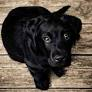

Image successfully extracted, encoded to base64, and displayed!


In [21]:
# Extract image using PyMuPDF, encode to base64, then visualize
import fitz  # PyMuPDF
import base64
from IPython.display import Image, display
import io

# Open the PDF file
pdf_path = "sample_data/sample_data.pdf"
pdf_document = fitz.open(pdf_path)

# Extract the first image found
for page_num in range(len(pdf_document)):
    page = pdf_document[page_num]
    image_list = page.get_images(full=True)
    
    if image_list:
        # Get the first image
        img = image_list[0]
        xref = img[0]
        pix = fitz.Pixmap(pdf_document, xref)
        
        # Convert to PNG bytes
        if pix.n - pix.alpha < 4:  # GRAY or RGB
            img_data = pix.tobytes("png")
        else:  # CMYK
            pix = fitz.Pixmap(fitz.csRGB, pix)
            img_data = pix.tobytes("png")
        
        # Encode to base64
        base64_string = base64.b64encode(img_data).decode('utf-8')
        print(f"Base64 string length: {len(base64_string)}")
        print(f"First 100 characters of base64: {base64_string[:100]}...")
        
        # Now decode the base64 string back and display
        decoded_img_data = base64.b64decode(base64_string)
        
        # Display the image from base64
        display(Image(data=decoded_img_data))
        print("Image successfully extracted, encoded to base64, and displayed!")
        
        pix = None  # Clean up
        break

pdf_document.close()